# From 8 minutes to 4 seconds
## Solving large systems with Jacobi + GMRES

**Romain Sacchi (PSI) · Brightcon 2026 · 25 September 2026 · 8 minutes**  
Open Tools and Development · Aalborg University & online

> Direct sparse factorisation is an excellent default—until fill-in makes memory and runtime scale much faster than the matrix itself. An iterative solve makes that trade-off explicit and controllable.


## Run of show

1. Start with bare synthetic technosphere matrices and solve $Ax=b$ five ways.
2. Scale the same matrix family while measuring runtime, peak RSS, iterations, and residuals.
3. Switch to `bw2calc.JacobiGMRESLCA` with one line of user-facing API change.
4. Compare 200 paired BAFU Monte Carlo samples on identical matrices.

The synthetic stress workers are deliberately uncapped so their actual factorisation times are visible. If a worker fails, the notebook uses committed calibration results and labels them as stored—not live—results.


In [1]:
from __future__ import annotations

import importlib.metadata
import json
import os
import subprocess
import sys
from pathlib import Path
from time import perf_counter

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import scipy
from IPython.display import Markdown, display
from scipy.sparse.linalg import LinearOperator, gmres, spsolve


def find_repo_root(start: Path = Path.cwd()) -> Path:
    for candidate in (start, *start.parents):
        if (candidate / "dev" / "benchmark_synthetic.py").exists():
            return candidate
    raise FileNotFoundError("Run this notebook from inside the repository")


ROOT = find_repo_root()
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

LIVE = os.environ.get("BRIGHTCON_LIVE", "1") != "0"
BW_PROJECT = os.environ.get("BRIGHTCON_BW_PROJECT", "brightcon-2026")
DATABASE = "bafu"
ACTIVITY_CODE = "bafu-219622"
METHOD = ("IPCC 2021", "climate change", "global warming potential (GWP100)")
SEED = 2026
RTOL = 1e-4

{
    "live workers": LIVE,
    "worker Python": sys.executable,
    "Brightway project": BW_PROJECT,
    "NumPy": np.__version__,
    "SciPy": scipy.__version__,
    "scikit-umfpack": importlib.metadata.version("scikit-umfpack"),
}


{'live workers': True,
 'worker Python': '/opt/homebrew/Caskroom/miniforge/base/envs/pathways/bin/python3',
 'Brightway project': 'clic-bafu-2025-ef31',
 'NumPy': '1.24.4',
 'SciPy': '1.15.2',
 'scikit-umfpack': '0.3.3'}

# 1 · Strip LCA down to $Ax=b$

- $A$: technosphere matrix—positive production diagonal, negative inputs.
- $b$: demand vector—one unit of the functional unit.
- $x$: supply array—how much each activity must produce.

The first matrix is deliberately ill-scaled across four orders of magnitude. This makes the purpose of diagonal preconditioning visible without any biosphere or characterization matrices.


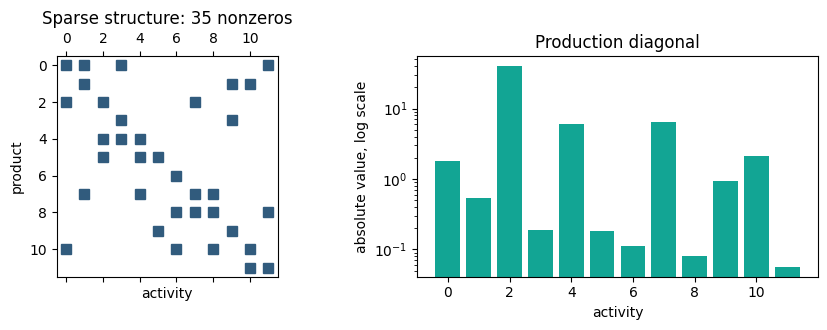

In [2]:
from dev.benchmark_synthetic import constant_degree_matrix

A_tiny = constant_degree_matrix(n=12, degree=2, seed=SEED, diagonal_span=4.0)
b_tiny = np.zeros(12)
b_tiny[0] = 1.0

fig, axes = plt.subplots(1, 2, figsize=(9, 3.4))
axes[0].spy(A_tiny, markersize=7, color="#315B7D")
axes[0].set_title(f"Sparse structure: {A_tiny.nnz} nonzeros")
axes[0].set_xlabel("activity")
axes[0].set_ylabel("product")
axes[1].bar(np.arange(12), np.abs(A_tiny.diagonal()), color="#12A594")
axes[1].set_yscale("log")
axes[1].set_title("Production diagonal")
axes[1].set_xlabel("activity")
axes[1].set_ylabel("absolute value, log scale")
fig.tight_layout()
plt.show()


## Five approaches, one solution

- Dense LAPACK through `numpy.linalg.solve`—useful only while $A$ is small.
- Sparse SuperLU and UMFPACK—robust direct factorisations.
- GMRES—approximate Krylov solve with an explicit residual tolerance.
- Jacobi + GMRES—left-precondition with $D^{-1}$, the reciprocal diagonal.

The entire Jacobi preconditioner is the `LinearOperator` below; no dense inverse is created.


In [3]:
def timed(function):
    started = perf_counter()
    value = function()
    return value, perf_counter() - started


def krylov(matrix, demand, *, jacobi: bool):
    history = []
    preconditioner = None
    if jacobi:
        inverse_diagonal = 1.0 / matrix.diagonal()
        preconditioner = LinearOperator(
            matrix.shape,
            matvec=lambda vector: inverse_diagonal * vector,
            dtype=matrix.dtype,
        )
    solution, info = gmres(
        matrix,
        demand,
        M=preconditioner,
        rtol=RTOL,
        atol=0.0,
        restart=50,
        maxiter=300,
        callback=history.append,
        callback_type="pr_norm",
    )
    return solution, info, len(history)


tiny_runs = []
for label, function in (
    ("NumPy dense", lambda: (np.linalg.solve(A_tiny.toarray(), b_tiny), None, 0)),
    ("SuperLU", lambda: (spsolve(A_tiny, b_tiny, use_umfpack=False), None, 0)),
    ("UMFPACK", lambda: (spsolve(A_tiny, b_tiny, use_umfpack=True), None, 0)),
    ("GMRES", lambda: krylov(A_tiny, b_tiny, jacobi=False)),
    ("Jacobi + GMRES", lambda: krylov(A_tiny, b_tiny, jacobi=True)),
):
    (solution, info, iterations), seconds = timed(function)
    residual = np.linalg.norm(A_tiny @ solution - b_tiny) / np.linalg.norm(b_tiny)
    tiny_runs.append(
        {"solver": label, "seconds": seconds, "iterations": iterations, "residual": residual, "info": info}
    )

pd.DataFrame(tiny_runs).style.format({"seconds": "{:.2e}", "residual": "{:.2e}"})


,solver,seconds,iterations,residual,info
0,NumPy dense,1.14e-04,0,1.51e-16,nan
1,SuperLU,2.52e-04,0,1.21e-17,nan
2,UMFPACK,2.53e-04,0,1.51e-16,nan
3,GMRES,6.68e-04,6,4.51e-05,0.000000
4,Jacobi + GMRES,2.99e-04,4,3.39e-05,0.000000


### Audience prompt

What happens to the benefit of Jacobi if every production diagonal is already one? The answer cell repeats the comparison on a unit-scaled matrix.


In [4]:
A_unit = constant_degree_matrix(n=500, degree=8, seed=SEED, diagonal_span=0.0)
b_unit = np.zeros(500)
b_unit[0] = 1.0
_, _, plain_iterations = krylov(A_unit, b_unit, jacobi=False)
_, _, jacobi_iterations = krylov(A_unit, b_unit, jacobi=True)
{"plain GMRES iterations": plain_iterations, "Jacobi + GMRES iterations": jacobi_iterations}


{'plain GMRES iterations': 4, 'Jacobi + GMRES iterations': 4}

# 2 · Scale the matrix, isolate every solver

Each solver runs in a fresh subprocess. This prevents one factorisation from contaminating the next solver's peak memory. A 2 ms RSS sampler captures allocations made by NumPy, SciPy, UMFPACK, and BLAS—not only Python objects. Incremental RSS is measured above the post-matrix-construction baseline.

Main series: approximately eight inputs per activity. Dense solving stops at 2,500 activities; the remaining isolated workers run to completion without a benchmark timeout.


In [5]:
def run_checked(command: list[str], timeout: float | None = None) -> subprocess.CompletedProcess[str]:
    return subprocess.run(
        command,
        cwd=ROOT,
        check=True,
        capture_output=True,
        text=True,
        timeout=timeout,
    )


def live_or_stored_synthetic():
    live_path = ROOT / "results" / "live_synthetic.json"
    fallback = ROOT / "results" / "synthetic_calibration.json"
    if LIVE:
        command = [
            sys.executable,
            "dev/run_synthetic_suite.py",
            "--python", sys.executable,
            "--output", str(live_path),
            "--sizes", "500", "1000", "2500", "5000", "10000",
            "--rtol", str(RTOL),
        ]
        try:
            run_checked(command)
            return json.loads(live_path.read_text()), "LIVE"
        except Exception as error:
            return json.loads(fallback.read_text()), f"STORED FALLBACK ({type(error).__name__})"
    return json.loads(fallback.read_text()), "STORED RESULTS"


synthetic_payload, synthetic_source = live_or_stored_synthetic()
display(Markdown(f"**Result source: {synthetic_source}**"))
synthetic = pd.json_normalize(synthetic_payload["results"])
synthetic["memory_mib"] = synthetic["incremental_peak_rss_bytes"] / 2**20
synthetic[["solver", "size", "solve_seconds", "memory_mib", "iterations", "relative_residual", "timed_out"]]


**Result source: LIVE**

,solver,size,solve_seconds,memory_mib,iterations,relative_residual,timed_out
0,numpy-dense,500,0.003327,5.375000,0,7.988388e-16,False
1,superlu,500,0.008044,2.281250,0,3.691832e-15,False
2,umfpack,500,0.005826,6.140625,0,5.612767e-16,False
3,gmres,500,0.026774,0.265625,181,9.842808e-05,False
4,jacobi-gmres,500,0.000417,0.078125,6,4.452165e-05,False
5,numpy-dense,1000,0.019914,20.234375,0,1.261468e-16,False
6,superlu,1000,0.060016,12.796875,0,7.419040e-16,False
7,umfpack,1000,0.020784,22.343750,0,1.113162e-16,False
8,gmres,1000,0.002042,0.156250,21,9.637978e-05,False
9,jacobi-gmres,1000,0.000504,0.156250,5,1.589369e-05,False


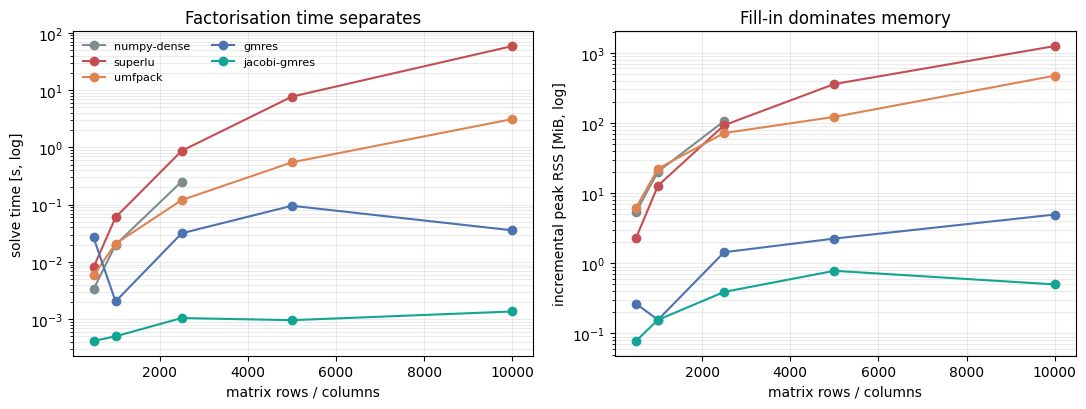

In [6]:
solver_order = ["numpy-dense", "superlu", "umfpack", "gmres", "jacobi-gmres"]
colors = {
    "numpy-dense": "#7F8C8D",
    "superlu": "#C44E52",
    "umfpack": "#DD8452",
    "gmres": "#4C72B0",
    "jacobi-gmres": "#12A594",
}

fig, axes = plt.subplots(1, 2, figsize=(11, 4.2))
valid = synthetic[synthetic["solve_seconds"].notna()]
for solver in solver_order:
    subset = valid[valid.solver == solver].sort_values("size")
    if subset.empty:
        continue
    axes[0].plot(subset["size"], subset["solve_seconds"], "o-", label=solver, color=colors[solver])
    axes[1].plot(subset["size"], subset["memory_mib"], "o-", label=solver, color=colors[solver])

axes[0].set_yscale("log")
axes[0].set_ylabel("solve time [s, log]")
axes[1].set_yscale("log")
axes[1].set_ylabel("incremental peak RSS [MiB, log]")
for axis in axes:
    axis.set_xlabel("matrix rows / columns")
    axis.grid(alpha=0.25, which="both")
axes[0].set_title("Factorisation time separates")
axes[1].set_title("Fill-in dominates memory")
axes[0].legend(frameon=False, ncol=2, fontsize=8)
fig.tight_layout()
plt.show()


## Uncapped fixed-density stress test

With constant density, nonzeros grow with $n^2$, not $n$. We sweep 5,000–20,000 rows at 0.1% density, then add a 20,000-row matrix at 0.2%. Every solver runs to completion in an isolated worker—there is no benchmark timeout. This is less typical of ordinary databases, but representative of increasingly interconnected or regionalized systems—and matches the stress-test logic in the conference abstract.


**Result sources: LIVE · LIVE**

,solver,size,target_density,nnz,solve_seconds,incremental_peak_MiB,iterations,relative_residual
0,umfpack,5000,0.001,29993,0.255153,67.765625,0,2.220446e-16
1,gmres,5000,0.001,29993,0.000517,0.265625,3,9.425565e-05
2,jacobi-gmres,5000,0.001,29993,0.000785,0.312500,4,4.134672e-06
3,umfpack,10000,0.001,109988,3.362409,475.421875,0,1.154322e-16
4,gmres,10000,0.001,109988,0.035491,4.687500,83,9.910508e-05
5,jacobi-gmres,10000,0.001,109988,0.002029,1.046875,6,5.667706e-05
6,umfpack,15000,0.001,239980,12.976669,1193.765625,0,4.440951e-16
7,gmres,15000,0.001,239980,0.099676,6.140625,48,9.674822e-05
8,jacobi-gmres,15000,0.001,239980,0.004859,1.375000,5,4.982256e-05
9,umfpack,20000,0.001,419982,37.546171,2305.890625,0,1.046834e-14


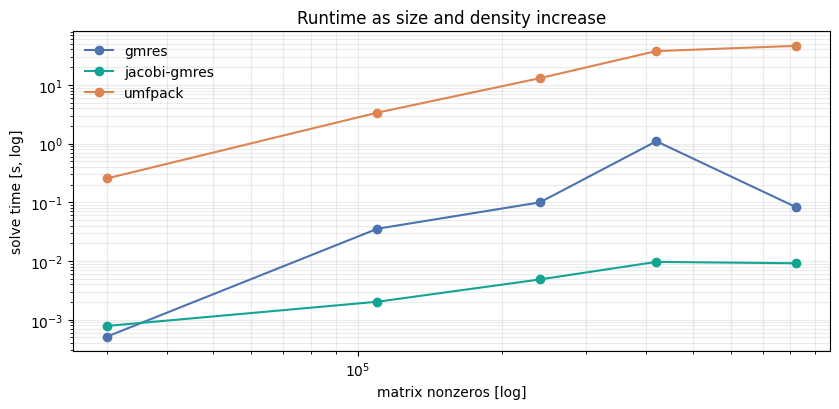

In [7]:
def live_or_stored_density(sizes: list[int], density: float, live_name: str, fallback_name: str):
    live_path = ROOT / "results" / live_name
    fallback = ROOT / "results" / fallback_name
    if LIVE:
        command = [
            sys.executable,
            "dev/run_synthetic_suite.py",
            "--python", sys.executable,
            "--output", str(live_path),
            "--sizes", *(str(size) for size in sizes),
            "--solvers", "umfpack", "gmres", "jacobi-gmres",
            "--topology", "fixed-density",
            "--density", str(density),
            "--rtol", str(RTOL),
        ]
        try:
            run_checked(command)
            return json.loads(live_path.read_text()), "LIVE"
        except Exception as error:
            return json.loads(fallback.read_text()), f"STORED FALLBACK ({type(error).__name__})"
    return json.loads(fallback.read_text()), "STORED RESULTS"


density_cases = [
    live_or_stored_density([5000, 10000, 15000, 20000], 0.001, "live_density.json", "synthetic_density_calibration.json"),
    live_or_stored_density([20000], 0.002, "live_dense_large.json", "synthetic_dense_large_calibration.json"),
]
display(Markdown("**Result sources: " + " · ".join(source for _, source in density_cases) + "**"))
density_results = pd.concat(
    [pd.json_normalize(payload["results"]) for payload, _ in density_cases],
    ignore_index=True,
)
density_results["incremental_peak_MiB"] = density_results["incremental_peak_rss_bytes"] / 2**20
display(density_results[["solver", "size", "target_density", "nnz", "solve_seconds", "incremental_peak_MiB", "iterations", "relative_residual"]])

fig, axis = plt.subplots(figsize=(8.5, 4.2))
for solver, subset in density_results.sort_values("nnz").groupby("solver"):
    axis.plot(subset["nnz"], subset["solve_seconds"], "o-", label=solver, color=colors[solver])
axis.set_xscale("log")
axis.set_yscale("log")
axis.set_xlabel("matrix nonzeros [log]")
axis.set_ylabel("solve time [s, log]")
axis.set_title("Runtime as size and density increase")
axis.grid(alpha=0.25, which="both")
axis.legend(frameon=False)
fig.tight_layout()
plt.show()


# 3 · The same switch inside Brightway

```python
from bw2calc import LCA, JacobiGMRESLCA

direct = LCA(demand, method=method)
iterative = JacobiGMRESLCA(
    demand,
    method=method,
    rtol=1e-4,
    use_guess=True,
)
```

The presentation project is prepared before the clock starts. The notebook validates the exact project, database, functional unit, and method; it does not import Excel live.


In [8]:
BW_READY = False
BW_ERROR = None
try:
    import bw2calc as bc
    import bw2data as bd

    if BW_PROJECT not in {project.name for project in bd.projects}:
        raise ValueError(f"Missing project: {BW_PROJECT}")
    bd.projects.set_current(BW_PROJECT)
    if DATABASE not in bd.databases:
        raise ValueError(f"Missing database: {DATABASE}")
    activity = bd.get_node(database=DATABASE, code=ACTIVITY_CODE)
    observed = (
        activity.get("name"), activity.get("reference product"),
        activity.get("location"), activity.get("unit"),
    )
    expected = (
        "Electricity, low voltage, at grid", "Electricity, low voltage, at grid",
        "CH", "kilowatt hour",
    )
    if observed != expected:
        raise ValueError(f"Unexpected functional unit: {observed}")
    if METHOD not in bd.methods:
        raise ValueError(f"Missing method: {METHOD}")
    BW_READY = True
except Exception as error:
    BW_ERROR = f"{type(error).__name__}: {error}"

{
    "ready for live BAFU workers": BW_READY and LIVE,
    "project": BW_PROJECT,
    "database": DATABASE,
    "activity": ACTIVITY_CODE,
    "method": METHOD,
    "preflight error": BW_ERROR,
}


{'ready for live BAFU workers': True,
 'project': 'clic-bafu-2025-ef31',
 'database': 'bafu',
 'activity': 'bafu-219622',
 'method': ('IPCC 2021',
  'climate change',
  'global warming potential (GWP100)'),
 'preflight error': None}

> **Scope and local workaround—recheck before Brightcon:** in our tests this affects stochastic `JacobiGMRESLCA` only. Its CSC preparation detaches the active technosphere matrix from the stochastic matrix manager, so later Monte Carlo iterations would reuse the first matrix. Direct `LCA` does not take this route, and deterministic Jacobi does not advance the matrix. The fix is **not** in the installed `bw2calc 2.5.0`; this repository adds an `after_matrix_iteration` rebind in the benchmark worker. Remove the local guard once the behavior is corrected upstream.


In [9]:
def run_bafu_worker(solver: str, iterations: int, stochastic: bool, output: Path):
    command = [
        sys.executable,
        "dev/benchmark_bafu.py",
        "--solver", solver,
        "--project", BW_PROJECT,
        "--iterations", str(iterations),
        "--output", str(output),
        "--quiet",
    ]
    if solver == "jacobi-gmres":
        command.extend(["--rtol", str(RTOL), "--use-guess"])
    if not stochastic:
        command.append("--no-stochastic")
    run_checked(command, timeout=45)
    return json.loads(output.read_text())


def deterministic_runs():
    fallback_direct = ROOT / "results" / "bafu_direct_deterministic.json"
    fallback_iterative = ROOT / "results" / "bafu_jacobi_deterministic.json"
    if LIVE and BW_READY:
        try:
            direct = run_bafu_worker("direct", 1, False, ROOT / "results" / "live_bafu_direct_deterministic.json")
            iterative = run_bafu_worker("jacobi-gmres", 1, False, ROOT / "results" / "live_bafu_jacobi_deterministic.json")
            return direct, iterative, "LIVE"
        except Exception as error:
            source = f"STORED FALLBACK ({type(error).__name__})"
    else:
        source = "STORED RESULTS"
    return json.loads(fallback_direct.read_text()), json.loads(fallback_iterative.read_text()), source


det_direct, det_iterative, deterministic_source = deterministic_runs()
display(Markdown(f"**Result source: {deterministic_source}**"))
pd.DataFrame([
    {
        "solver": "UMFPACK",
        "seconds": det_direct["calculation_seconds"],
        "incremental peak MiB": det_direct["incremental_peak_rss_bytes"] / 2**20,
        "score": det_direct["records"][0]["score"],
        "relative residual": det_direct["records"][0]["relative_residual"],
    },
    {
        "solver": "Jacobi + GMRES",
        "seconds": det_iterative["calculation_seconds"],
        "incremental peak MiB": det_iterative["incremental_peak_rss_bytes"] / 2**20,
        "score": det_iterative["records"][0]["score"],
        "relative residual": det_iterative["records"][0]["relative_residual"],
    },
]).style.format({"seconds": "{:.3f}", "incremental peak MiB": "{:.1f}", "score": "{:.8f}", "relative residual": "{:.2e}"})


**Result source: LIVE**

,solver,seconds,incremental peak MiB,score,relative residual
0,UMFPACK,0.051,23.4,0.09707146,4.63e-16
1,Jacobi + GMRES,0.039,4.1,0.09704688,6.35e-05


# 4 · 200 paired BAFU Monte Carlo samples at `rtol=1e-4`

- Functional unit: **1 kWh Swiss low-voltage electricity at grid**.
- Impact: **IPCC 2021 GWP100**.
- Both solvers receive the same seed and identical sampled technosphere and biosphere matrices.
- Each pair is accepted only if both matrix fingerprints match.
- Jacobi+GMRES uses `rtol=1e-4` and `use_guess=True`, reusing the preceding supply array as its initial guess.


In [10]:
from dev.compare_bafu_runs import summarize


def monte_carlo_runs():
    fallback_direct = ROOT / "results" / "bafu_direct_200.json"
    fallback_iterative = ROOT / "results" / "bafu_jacobi_200.json"
    if LIVE and BW_READY:
        try:
            direct = run_bafu_worker("direct", 200, True, ROOT / "results" / "live_bafu_direct_200.json")
            iterative = run_bafu_worker("jacobi-gmres", 200, True, ROOT / "results" / "live_bafu_jacobi_200.json")
            return direct, iterative, "LIVE"
        except Exception as error:
            source = f"STORED FALLBACK ({type(error).__name__})"
    else:
        source = "STORED RESULTS"
    return json.loads(fallback_direct.read_text()), json.loads(fallback_iterative.read_text()), source


mc_direct, mc_iterative, mc_source = monte_carlo_runs()
mc_summary = summarize(mc_direct, mc_iterative)  # Raises if any paired fingerprint differs.
display(Markdown(f"**Result source: {mc_source} · paired fingerprints match: YES**"))

pd.DataFrame([
    {
        "solver": "UMFPACK",
        "200 samples [s]": mc_summary["direct"]["calculation_seconds"],
        "median iteration [ms]": mc_summary["direct"]["median_iteration_seconds_excluding_first"] * 1000,
        "incremental peak [MiB]": mc_summary["direct"]["incremental_peak_rss_bytes"] / 2**20,
        "median GMRES iterations": np.nan,
        "warm start": "—",
    },
    {
        "solver": "Jacobi + GMRES",
        "200 samples [s]": mc_summary["jacobi_gmres"]["calculation_seconds"],
        "median iteration [ms]": mc_summary["jacobi_gmres"]["median_iteration_seconds_excluding_first"] * 1000,
        "incremental peak [MiB]": mc_summary["jacobi_gmres"]["incremental_peak_rss_bytes"] / 2**20,
        "median GMRES iterations": mc_summary["jacobi_gmres"]["median_gmres_iterations"],
        "warm start": "yes",
    },
]).style.format({"200 samples [s]": "{:.2f}", "median iteration [ms]": "{:.1f}", "incremental peak [MiB]": "{:.1f}", "median GMRES iterations": "{:.0f}"})


**Result source: LIVE · paired fingerprints match: YES**

,solver,200 samples [s],median iteration [ms],incremental peak [MiB],median GMRES iterations,warm start
0,UMFPACK,14.14,64.6,89.3,nan,—
1,Jacobi + GMRES,10.51,46.6,72.0,19,yes


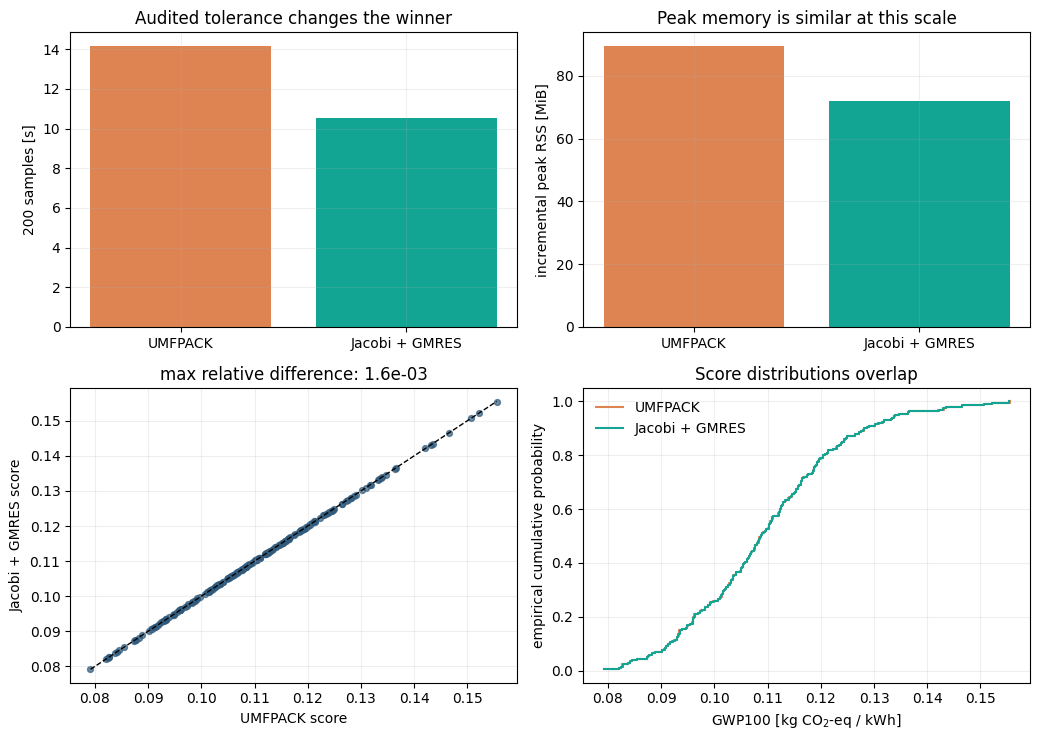

In [11]:
direct_scores = np.array([record["score"] for record in mc_direct["records"]])
iterative_scores = np.array([record["score"] for record in mc_iterative["records"]])

fig, axes = plt.subplots(2, 2, figsize=(10.5, 7.5))
labels = ["UMFPACK", "Jacobi + GMRES"]
axes[0, 0].bar(labels, [mc_summary["direct"]["calculation_seconds"], mc_summary["jacobi_gmres"]["calculation_seconds"]], color=["#DD8452", "#12A594"])
axes[0, 0].set_ylabel("200 samples [s]")
axes[0, 0].set_title("Audited tolerance changes the winner")

axes[0, 1].bar(labels, [mc_summary["direct"]["incremental_peak_rss_bytes"] / 2**20, mc_summary["jacobi_gmres"]["incremental_peak_rss_bytes"] / 2**20], color=["#DD8452", "#12A594"])
axes[0, 1].set_ylabel("incremental peak RSS [MiB]")
axes[0, 1].set_title("Peak memory is similar at this scale")

limits = [min(direct_scores.min(), iterative_scores.min()), max(direct_scores.max(), iterative_scores.max())]
axes[1, 0].scatter(direct_scores, iterative_scores, s=18, alpha=0.7, color="#315B7D")
axes[1, 0].plot(limits, limits, "--", color="black", linewidth=1)
axes[1, 0].set_xlabel("UMFPACK score")
axes[1, 0].set_ylabel("Jacobi + GMRES score")
axes[1, 0].set_title(f"max relative difference: {mc_summary['score_agreement']['maximum_relative_difference']:.1e}")

for values, label, color in ((direct_scores, "UMFPACK", "#DD8452"), (iterative_scores, "Jacobi + GMRES", "#12A594")):
    ordered = np.sort(values)
    axes[1, 1].step(ordered, np.arange(1, len(ordered) + 1) / len(ordered), where="post", label=label, color=color)
axes[1, 1].set_xlabel("GWP100 [kg CO$_2$-eq / kWh]")
axes[1, 1].set_ylabel("empirical cumulative probability")
axes[1, 1].set_title("Score distributions overlap")
axes[1, 1].legend(frameon=False)

for axis in axes.ravel():
    axis.grid(alpha=0.2)
fig.tight_layout()
plt.show()


## Dataset-wide fixed-matrix check: first 100 BAFU activities

This is separate from Monte Carlo: the technosphere, biosphere, and characterization matrices are built once, then each of the first 100 BAFU activities is scored as a one-unit demand. UMFPACK factorizes once on the first demand and reuses that factorization; Jacobi+GMRES uses `rtol=1e-4` and `use_guess=True`.


**Result source: LIVE · same activity order: YES**

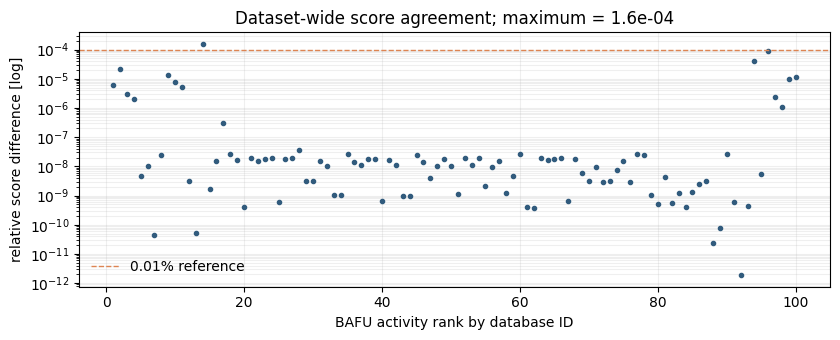

In [12]:
from dev.compare_bafu_all_activities import summarize as summarize_all_activities


def all_activity_runs():
    fallback_direct = ROOT / "results" / "bafu_all_direct_100.json"
    fallback_iterative = ROOT / "results" / "bafu_all_jacobi_100.json"
    if LIVE and BW_READY:
        try:
            direct_command = [
                sys.executable, "dev/benchmark_bafu_all_activities.py",
                "--solver", "direct", "--project", BW_PROJECT, "--limit", "100",
                "--output", str(ROOT / "results" / "live_bafu_all_direct_100.json"),
            ]
            iterative_command = [
                sys.executable, "dev/benchmark_bafu_all_activities.py",
                "--solver", "jacobi-gmres", "--project", BW_PROJECT, "--limit", "100",
                "--rtol", str(RTOL), "--use-guess",
                "--output", str(ROOT / "results" / "live_bafu_all_jacobi_100.json"),
            ]
            run_checked(direct_command, timeout=240)
            run_checked(iterative_command, timeout=240)
            return (
                json.loads((ROOT / "results" / "live_bafu_all_direct_100.json").read_text()),
                json.loads((ROOT / "results" / "live_bafu_all_jacobi_100.json").read_text()),
                "LIVE",
            )
        except Exception as error:
            source = f"STORED FALLBACK ({type(error).__name__})"
    else:
        source = "STORED RESULTS"
    return json.loads(fallback_direct.read_text()), json.loads(fallback_iterative.read_text()), source


all_direct, all_iterative, all_source = all_activity_runs()
all_summary = summarize_all_activities(all_direct, all_iterative)
display(Markdown(f"**Result source: {all_source} · same activity order: YES**"))
pd.DataFrame([
    {
        "solver": "UMFPACK",
        "100 dataset scores [s]": all_summary["direct"]["calculation_seconds"],
        "per dataset [ms]": all_summary["direct"]["seconds_per_activity"] * 1000,
        "incremental peak [MiB]": all_summary["direct"]["incremental_peak_rss_bytes"] / 2**20,
        "factorized once": "yes",
    },
    {
        "solver": "Jacobi + GMRES",
        "100 dataset scores [s]": all_summary["jacobi_gmres"]["calculation_seconds"],
        "per dataset [ms]": all_summary["jacobi_gmres"]["seconds_per_activity"] * 1000,
        "incremental peak [MiB]": all_summary["jacobi_gmres"]["incremental_peak_rss_bytes"] / 2**20,
        "factorized once": "no",
    },
]).style.format({"100 dataset scores [s]": "{:.2f}", "per dataset [ms]": "{:.2f}", "incremental peak [MiB]": "{:.1f}"})

direct_activity_scores = np.array([record["score"] for record in all_direct["records"]])
iterative_activity_scores = np.array([record["score"] for record in all_iterative["records"]])
relative_activity_difference = np.abs(iterative_activity_scores - direct_activity_scores) / np.maximum(np.abs(direct_activity_scores), np.finfo(float).tiny)
fig, axis = plt.subplots(figsize=(8.5, 3.5))
axis.plot(np.arange(1, len(relative_activity_difference) + 1), relative_activity_difference, ".", color="#315B7D")
axis.axhline(1e-4, linestyle="--", color="#DD8452", linewidth=1, label="0.01% reference")
axis.set_yscale("log")
axis.set_xlabel("BAFU activity rank by database ID")
axis.set_ylabel("relative score difference [log]")
axis.set_title(f"Dataset-wide score agreement; maximum = {relative_activity_difference.max():.1e}")
axis.grid(alpha=0.2, which="both")
axis.legend(frameon=False)
fig.tight_layout()
plt.show()


# Takeaways

1. **Tolerance can change the winner.** At `rtol=1e-4`, warm-started Jacobi+GMRES overtakes UMFPACK on the 11,747-row BAFU system.
2. **The crossover is structural.** As random cross-links and density generate fill-in, direct runtime and RAM rise sharply.
3. **Approximation must be audited.** Report `rtol`, GMRES status, the measured $Ax-b$ residual, and score agreement.
4. **Monte Carlo comparisons must be paired.** Equal seeds are not enough—verify matrix fingerprints.
5. **Dataset-wide scores are a different workload.** Reusing one direct factorization makes UMFPACK competitive for many demands; iterative methods should be judged on both solve time and score agreement.
6. **Large systems change the practical limit.** Jacobi+GMRES avoids factorisation and can move a calculation from minutes to seconds while retaining controlled accuracy.

> Use direct solving by default; switch when measured factorisation cost—not fashion—justifies it.


## Presenter preflight—not part of the timed talk

- Run once on the conference VM with `BRIGHTCON_LIVE=1`.
- Confirm the project is `brightcon-2026`, database is `bafu`, and activity code is `bafu-219622`.
- Confirm the direct backend is UMFPACK or explicitly relabel it if Pardiso is used.
- Recheck whether the repository-local stochastic `JacobiGMRESLCA` matrix-rebinding guard is still needed in the installed `bw2calc`.
- Keep the committed results as a fallback, but never present them as live output.
